# LAPORAN PRAKTIKUM KECERDASAN ARTIFISIAL LANJUT
**Nama: Sayyidah Fatimah Azzahra**

**NIM: 235150200111064**

**Kelas: KAL-E**

---
## Bab 8. Algoritma Prediksi Menggunakan Regresi

In [263]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Tugas A (Regresi Linier)
Buat dataset sintetis baru dengan rumus:

$y=7+2.5x+ε, ε~N(0,1)$

Gunakan 200 data acak dari rentang x € [0,5]. Implementasikan algoritma regresi linier dari awal menggunakan gradient descent. Cetak nilai akhir dari parameter w0 dan w1.

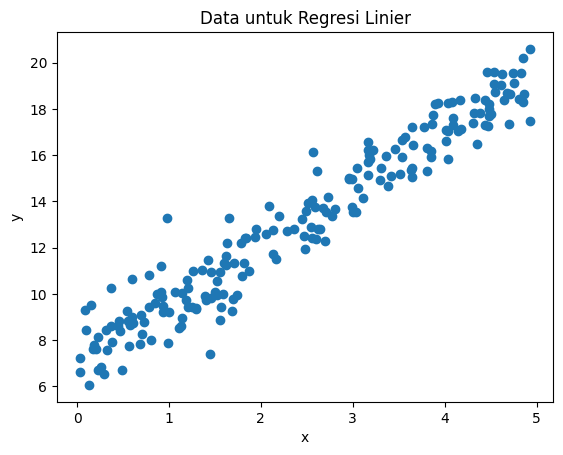

In [264]:
np.random.seed(42)

x = np.random.uniform(0, 5, 200)
epsilon = np.random.normal(0, 1, 200)
y = 7 + 2.5 * x + epsilon

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt. title("Data untuk Regresi Linier")
plt.show()

In [265]:
w0 = 0
w1 = 0
alpha = 0.1
epochs = 1000
m = len(x)

def gradient_descent_lin(x, y, w0, w1, alpha, epochs, m):
    for epoch in range(epochs):
        y_pred = w0 + w1 * x
        error = y_pred - y
        grad0 = (2/m) * np.sum(error)
        grad1 = (2/m) * np.sum (error * x)

        w0 -= alpha * grad0
        w1 -= alpha * grad1
    return w0, w1

w0_update, w1_update = gradient_descent_lin(x, y, w0, w1, alpha, epochs, m)
print(f"w0: {w0_update}, w1: {w1_update}")

w0: 7.105201150960817, w1: 2.484385786365007


##### 1. Hitung dan tampilkan: 

• Nilai Mean Squared Error (MSE)

• Plot garis regresi di atas data

In [266]:
# mse

def mse(y, y_pred):
    y = np.array(y)
    y_pred = np.array(y_pred)

    if y.ndim > 1:
        y = y.flatten()
    if y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    
    return np.mean((y - y_pred) ** 2)

y_pred = w0_update + w1_update * x
print("Mean Squared Error:", mse(y, y_pred))

Mean Squared Error: 0.9338262007909792


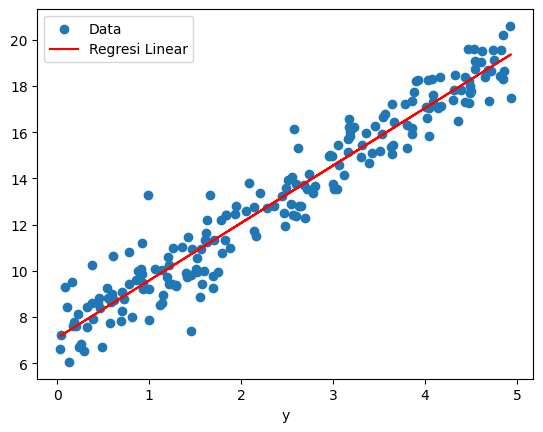

In [267]:
# plot garis regresi

def plot_lin(x, y, y_pred, title):
    plt.scatter(x, y, label="Data")
    plt.plot(x, y_pred, color="red", label="Regresi Linear")
    plt.xlabel("x")
    plt.xlabel("y")
    plt.legend()
    plt.show()

plot_lin(x, y, y_pred, "Regresi Linear")

##### 2. Ubah nilai learning rate (a) menjadi 0.001 dan 1.0. Amati dan jelaskan perbedaan konvergensinya.

In [268]:
w0_test, w1_test = gradient_descent_lin(x, y, w0, w1, 0.001, epochs, m)
w0_test1, w1_test1 = gradient_descent_lin(x, y, w0, w1, 1, epochs, m)
print(f"w0: {w0_test}, w1: {w1_test}")
print(f"w0: {w0_test1}, w1: {w1_test1}")

w0: 3.580458406011621, w1: 3.581752815078557
w0: nan, w1: nan


/var/folders/qj/rbjn75cn3gj4g8pvn3j12c0h0000gn/T/ipykernel_56187/4189818247.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  w1 -= alpha * grad1


In [269]:
y_pred_test = w0_test + w1_test * x
y_pred_test1 = w0_test1 + w1_test1 * x

print("Mean Squared Error (a = 0.001):", mse(y, y_pred_test))
print("Mean Squared Error (a = 1):", mse(y, y_pred_test1))

Mean Squared Error (a = 0.001): 4.294027756704498
Mean Squared Error (a = 1): nan


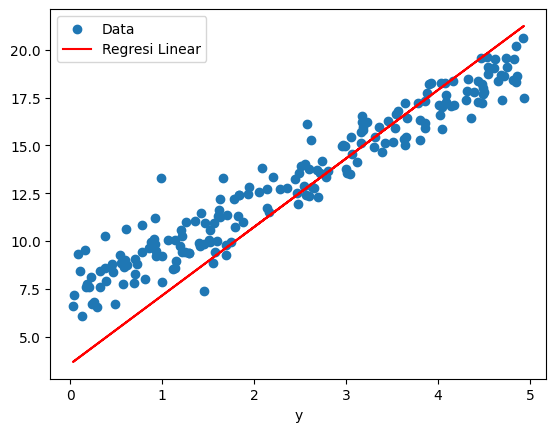

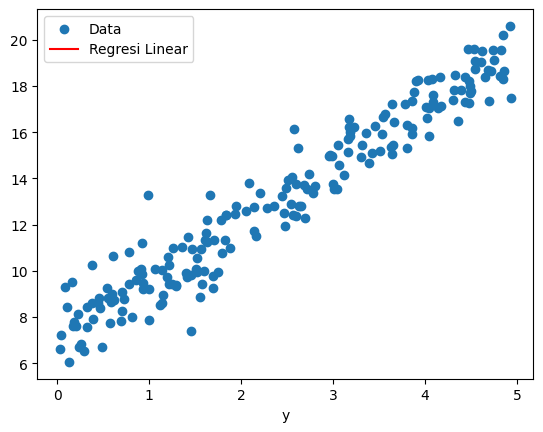

In [270]:
plot_lin(x, y, y_pred_test, 'Regresi Linear (a = 0.001)')
plot_lin(x, y, y_pred_test1, 'Regresi Linear (a = 1)')

#### Penjelasan

Pada eksperimen perubahan learning rate dari 0.1 menjadi 0.001 dan 1.0, saya mengamati perbedaan konvergensi sebagai berikut:

- α = 0.001 (terlalu kecil): Model konvergen jauh lebih lambat, hanya mencapai w0 = 3.58 dan w1 = 3.58 setelah 1000 epoch. Ini cukup jauh dari parameter sebenarnya (7 dan 2.5), menghasilkan MSE yang jauh lebih tinggi yaitu 4.29 dibandingkan dengan MSE model awal sebesar 0.93. Plot menunjukkan bahwa garis regresi jelas tidak sesuai dengan data dengan baik.
- α = 1.0 (terlalu besar): Model sama sekali gagal konvergen, menghasilkan nilai NaN untuk kedua parameter. Learning rate yang tinggi menyebabkan pembaruan gradien melampaui batas secara dramatis, yang mengakibatkan overflow numerik seperti yang ditunjukkan oleh peringatan runtime. Model pada dasarnya "meledak" dan tidak dapat menemukan solusi yang stabil.

Hal ini menunjukkan pentingnya pemilihan learning rate yang tepat dalam gradient descent. **Rate yang terlalu kecil menyebabkan konvergensi lambat, sedangkan rate yang terlalu besar dapat menyebabkan algoritma gagal konvergen sama sekali**.

### Tugas B (Regresi Polinomial)

Buat dataset sintetis baru dengan pola kuadratik:

$y = 5-1.2x + 0.9x^2 + ε$

Gunakan 150 data acak dari x € [-2,2]

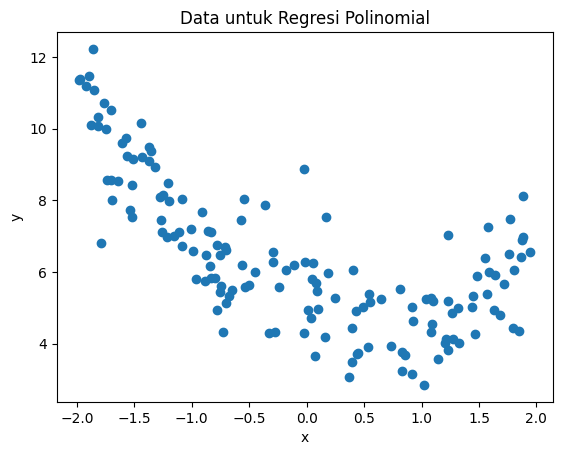

In [271]:
np.random.seed(42)

x = np.random.uniform(-2, 2, 150)
epsilon = np.random.normal(0, 1, 150)
y = 5 - 1.2 * x + 0.9 * x**2 + epsilon

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt. title("Data untuk Regresi Polinomial")
plt.show()

##### 1. Buat regresi polinomial derajat 2 dari awal. Implementasikan gradient descent dan tampilkan parameter W0, W1, W2.

In [272]:
m = len(x)
# x_poly = np.hstack((np.ones((m, 1)), x, x**2))
x_poly = np.column_stack((np.ones(m), x, x**2))
w = np.zeros((x_poly.shape[1], 1))
alpha = 0.01
epochs = 1000

In [273]:
def gradient_descent_poly(x_poly, y, w, alpha, epochs, m):
    y = y.reshape(-1, 1)

    for epoch in range(epochs):
        y_pred = x_poly @ w
        error = y_pred - y
        gradients = (2/m) * x_poly.T @ error
        w -= alpha * gradients
    return w

w_poly = gradient_descent_poly(x_poly, y, w, alpha, epochs, m)

print(f"Coefficients: w0={w_poly[0][0]:.4f}, w1={w_poly[1][0]:.4f}, w2={w_poly[2][0]:.4f}")

Coefficients: w0=5.0090, w1=-1.1549, w2=0.9294


In [274]:
# plot garis polinomial

x_plot = np. linspace(-2, 2, 100).reshape(-1, 1)
x_poly_plot = np.hstack((np.ones_like(x_plot), x_plot, x_plot**2))
y_plot = x_poly_plot @ w_poly

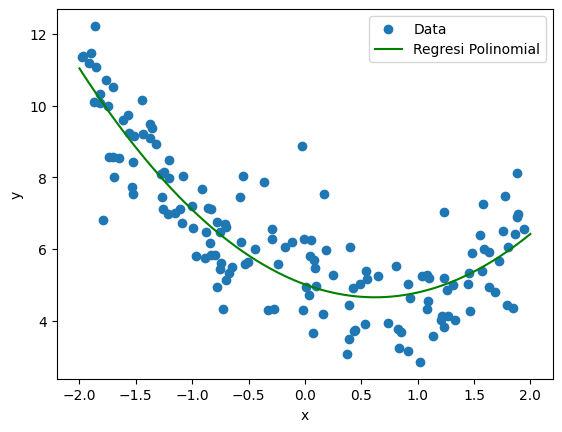

In [275]:
def plot_poly(x, y, x_plot, y_plot):
    plt.scatter(x, y, label="Data")
    plt.plot(x_plot, y_plot, color="green", label="Regresi Polinomial")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

plot_poly(x, y, x_plot, y_plot)

##### 2. Bandingkan MSE antara: 

• Regresi linier (fit hanya wo + W1x)

• Regresi polinomial (fit hingga w2 x^2)

In [276]:
# model regresi linier (hanya w0 + w1*x)
x_linear = np.column_stack((np.ones(m), x))
w_linear = np.zeros((x_linear.shape[1], 1))
w_linear = gradient_descent_poly(x_linear, y.reshape(-1, 1), w_linear, alpha, epochs, m)

# model regresi polinomial (fit hingga w2 x^2)
x_poly = np.column_stack((np.ones(m), x, x**2))
w = np.zeros((x_poly.shape[1], 1))
w_poly = gradient_descent_poly(x_poly, y.reshape(-1, 1), w, alpha, epochs, m)

# prediksi hasil kedua model
y_pred_linear = x_linear @ w_linear
y_pred_poly = x_poly @ w_poly

mse_linear = mse(y, y_pred_linear)
mse_poly = mse(y, y_pred_poly)

print(f"MSE Model Linear: {mse_linear:.4f}")
print(f"MSE Model Polinomial: {mse_poly:.4f}")
print(f"Rasio MSE Linear/Polinomial: {mse_linear/mse_poly:.4f}")

MSE Model Linear: 2.2598
MSE Model Polinomial: 1.0539
Rasio MSE Linear/Polinomial: 2.1443


##### 3. Visualisasikan kedua model regresi pada grafik yang sama dan diskusikan model mana yang lebih baik? Apa indikatornya?

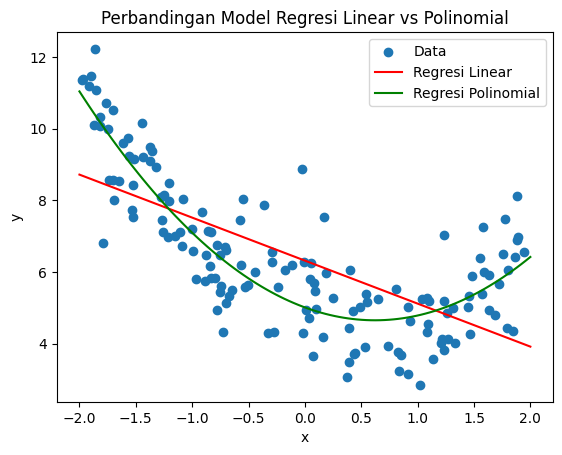

In [277]:
# persiapan plot data
x_plot = np.linspace(-2, 2, 100).reshape(-1, 1)

# fitur prediksi model linear
x_linear_plot = np.hstack((np.ones_like(x_plot), x_plot))
y_linear_plot = x_linear_plot @ w_linear

# fitur prediksi model polinomial
x_poly_plot = np.hstack((np.ones_like(x_plot), x_plot, x_plot**2))
y_poly_plot = x_poly_plot @ w_poly

plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_linear_plot, color='red', label=f"Regresi Linear")
plt.plot(x_plot, y_poly_plot, color='green', label=f"Regresi Polinomial")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Perbandingan Model Regresi Linear vs Polinomial")
plt.legend()
plt.show()

#### Penjelasan

Pada perbandingan model linear dan polinomial, saya menemukan bahwa:

1. **MSE Model Polinomial (1.0539) jauh lebih rendah dibandingkan MSE Model Linear (2.2598)**, menunjukkan pengurangan error sebesar 53%.

2. **Visualisasi** menunjukkan model polinomial mengikuti pola kurva data dengan baik, sementara model linear hanya bisa menangkap tren garis lurus dan tidak mampu mengikuti bentuk kuadratik data.

3. **Model polinomial lebih cocok** karena data memang dibuat dengan fungsi kuadratik (y = 5 - 1.2x + 0.9x² + ε), sehingga perlu model dengan kompleksitas setara untuk menangkapnya dengan tepat.

Kesimpulannya, model harus memiliki kompleksitas yang sesuai dengan pola data yang sebenarnya. Model linear terlalu sederhana (underfitting) untuk data kuadratik ini.

### Tugas C (Eksplorasi dan Analisis)

##### 1. Tambahkan derajat polinomial menjadi 5 (quintik). Apakah model menjadi lebih baik atau justru overfitting?

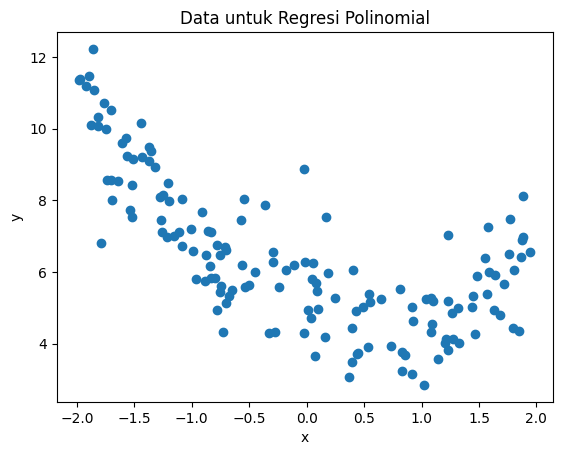

In [278]:
np.random.seed(42)

x = np.random.uniform(-2, 2, 150)
epsilon = np.random.normal(0, 1, 150)
y = 5 - 1.2 * x + 0.9 * x**2 + epsilon

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Data untuk Regresi Polinomial")
plt.show()

In [279]:
m = len(x)
alpha = 0.001
epochs = 1000

x_poly_5 = np.column_stack((np.ones(m), x, x**2, x**3, x**4, x**5))
w_poly_5 = np.zeros((x_poly_5.shape[1], 1))

w_poly_5 = gradient_descent_poly(x_poly_5, y, w_poly_5, alpha, epochs, m)

y_pred_poly_5 = x_poly_5 @ w_poly_5

mse_poly_5 = mse(y, y_pred_poly_5)

print(f"MSE Model Polinomial 5 Derajat: {mse_poly_5:.4f}")

MSE Model Polinomial 5 Derajat: 2.1818


##### 2. Buat fungsi predict(x, w) yang menerima data baru dan bobot hasil training, lalu mengembalikan hasil prediksi.

In [280]:
def predict(x, w):
    X = np.column_stack([x**i for i in range(len(w) - 1+1)])
    y_pred = X @ w
    return y_pred

In [281]:
x_test = np.array([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])

# 1. Prediksi dengan model linear (2 parameter: w0, w1)
print("Prediksi dengan model linear:")
y_pred_linear = predict(x_test, w_linear)
print(y_pred_linear.flatten())

# 2. Prediksi dengan model polinomial derajat 2 (3 parameter: w0, w1, w2)
print("\nPrediksi dengan model polinomial derajat 2:")
y_pred_poly2 = predict(x_test, w_poly)
print(y_pred_poly2.flatten())

# 3. Prediksi dengan model polinomial derajat 5 (6 parameter: w0, w1, w2, w3, w4, w5)
print("\nPrediksi dengan model polinomial derajat 5:")
y_pred_poly5 = predict(x_test, w_poly_5)
print(y_pred_poly5.flatten())

Prediksi dengan model linear:
[8.11516312 7.51517686 6.9151906  6.31520433 5.71521807 5.11523181
 4.51524555]

Prediksi dengan model polinomial derajat 2:
[8.83268105 7.09341103 5.81886009 5.00902822 4.66391544 4.78352172
 5.36784709]

Prediksi dengan model polinomial derajat 5:
[8.7130043  5.99961944 4.1859709  3.40550456 3.38862686 3.87613801
 5.03266515]


In [282]:
x_plot = np.linspace(-2, 2, 100).reshape(-1, 1)

# 1. Prediksi model linear
x_linear_plot = np.column_stack((np.ones(len(x_plot)), x_plot))
y_linear_plot = x_linear_plot @ w_linear

# 2. Prediksi model polinomial derajat 2
x_poly2_plot = np.column_stack((np.ones(len(x_plot)), x_plot, x_plot**2))
y_poly2_plot = x_poly2_plot @ w_poly

# 3. Prediksi model polinomial derajat 5
x_poly5_plot = np.column_stack((np.ones(len(x_plot)), x_plot, x_plot**2, x_plot**3, x_plot**4, x_plot**5))
y_poly5_plot = x_poly5_plot @ w_poly_5

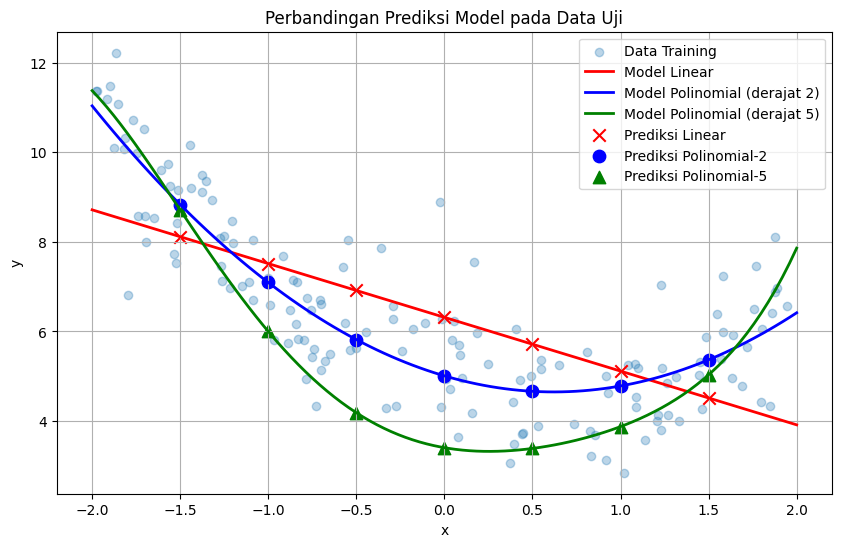

In [283]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.3, label="Data Training")
plt.plot(x_plot, y_linear_plot, color='red', linewidth=2, label="Model Linear")
plt.plot(x_plot, y_poly2_plot, color='blue', linewidth=2, label="Model Polinomial (derajat 2)")
plt.plot(x_plot, y_poly5_plot, color='green', linewidth=2, label="Model Polinomial (derajat 5)")

plt.scatter(x_test, y_pred_linear, color='red', s=80, marker='x', label="Prediksi Linear")
plt.scatter(x_test, y_pred_poly2, color='blue', s=80, marker='o', label="Prediksi Polinomial-2")
plt.scatter(x_test, y_pred_poly5, color='green', s=80, marker='^', label="Prediksi Polinomial-5")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Perbandingan Prediksi Model pada Data Uji")
plt.legend()
plt.grid(True)
plt.show()

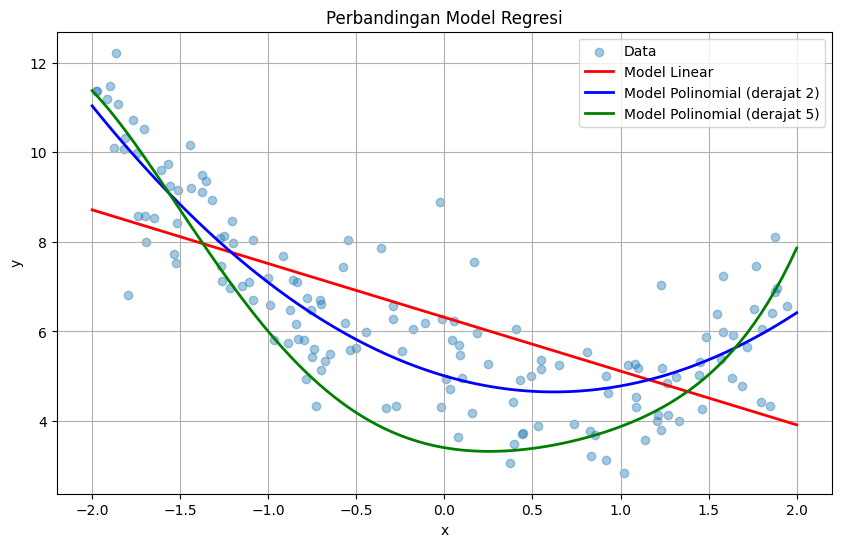

In [284]:
def plot_multiple_models(x, y, x_plot, y_plots, labels, colors=['red', 'blue', 'green'], title="Perbandingan Model Regresi"):
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.4, label="Data")
    
    for i, y_plot in enumerate(y_plots):
        plt.plot(x_plot, y_plot, color=colors[i], linewidth=2, label=labels[i])
    
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_multiple_models(
    x, y, x_plot, 
    [y_linear_plot, y_poly2_plot, y_poly5_plot],
    ["Model Linear", "Model Polinomial (derajat 2)", "Model Polinomial (derajat 5)"]
)

##### 3. Tulis kesimpulan Anda:
• Kapan kita perlu menggunakan regresi linier?

• Kapan regresi polinomial lebih cocok?

• Apa dampak jumlah epoch dan learning rate terhadap performa training?

#### Penjelasan

Berdasarkan eksperimen dengan model polinomial derajat 5 dan perbandingannya dengan model-model lain, saya menyimpulkan sebagai berikut:

1. **Kapan menggunakan regresi linier:**

- Untuk hubungan linier antar variabel
- Ketika interpretabilitas model lebih penting
- Saat data terbatas dan perlu menghindari overfitting
- Bila membutuhkan model yang komputasinya efisien

2. **Kapan regresi polinomial lebih cocok:**

- Saat data menunjukkan tren non-linier yang jelas
- Ketika MSE model linier tetap tinggi meski sudah dioptimalkan
- Bila ada alasan teoretis bahwa hubungan mengikuti fungsi polinomial
- Jika kualitas prediksi lebih penting dari kesederhanaan model

3. **Dampak epoch dan learning rate:**
- Epoch: Terlalu sedikit menyebabkan underfitting, terlalu banyak bisa menyebabkan overfitting
- Learning rate: Nilai α=0.001 terlalu kecil (konvergensi lambat), α=1.0 terlalu besar (gradien meledak)
- Perlu keseimbangan untuk mencapai konvergensi optimal

Dari percobaan ini, model polinomial derajat 2 memberikan hasil terbaik (MSE=1.05) sesuai dengan fungsi asli data, sementara model derajat 5 menunjukkan tanda overfitting dengan MSE lebih tinggi (2.18) dan kurva yang berfluktuasi berlebihan.

### KESIMPULAN

Pada praktikum ini, telah dilakukan implementasi regresi linier dan regresi polinomial dari awal (from scratch) tanpa menggunakan library machine learning seperti scikit-learn. Secara keseluruhan, praktikum ini memberikan pemahaman mendalam tentang konsep dasar regresi, algoritma optimasi, serta evaluasi performa model prediktif berbasis MSE.

Setelah melakukan praktikum ini mahasiswa diwajibkan untuk membuat kesimpulan.

Kesimpulan dari percobaan ini merupakan bagian penting untuk merangkum temuan utama dan relevansinya dengan tujuan percobaan. Mahasiswa harus mampu menyimpulkan:

• Apakah tujuan percobaan telah tercapai.

• Hubungan antara hasil percobaan dan dasar teori.

• Faktor-faktor yang memengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang terjadi.

Kesimpulan harus disusun secara singkat, jelas, dan berdasarkan data yang diperoleh.

### PENJELASAN

Pada praktikum ini, saya telah berhasil mengimplementasikan algoritma regresi linier dan polinomial from scratch.

Hasil percobaan saya menunjukkan kesesuaian yang kuat dengan dasar teori. Pada regresi linier (y = 7 + 2.5x + ε), saya memperoleh w0 = 7.105 dan w1 = 2.484 yang sangat mendekati nilai aslinya. Begitu juga pada regresi polinomial (y = 5 - 1.2x + 0.9x² + ε), di mana model berhasil menghasilkan koefisien w0 = 5.009, w1 = -1.155, dan w2 = 0.929, hampir identik dengan parameter asli.

Beberapa faktor yang saya temukan sepanjang percobaan saya adalah sebagai berikut:
1. Pemilihan learning rate yang tepat (terlalu kecil menyebabkan konvergensi lambat, terlalu besar menyebabkan divergensi)
2. Kesesuaian kompleksitas model dengan pola data (model derajat 2 optimal untuk data kuadratik, sedangkan model derajat 5 menunjukkan tanda overfitting)
3. Noise bawaan dalam data membatasi MSE minimum yang dapat dicapai
4. Kesalahan yang mungkin terjadi termasuk ketidakstabilan numerik pada gradient descent dengan learning rate tinggi dan keterbatasan dalam menemukan minimum global
